***Data Dictionary:***

there are two csv files given


**train_1.csv :**

In the csv file, each row corresponds to a particular article and each column correspond to a particular date. The values are the number of visits in that date.


**Exog_Campaign_eng :**

This file contaings data for the dates which had a campaign or significant event that could affect the views for that day.
the data is just for pages in english.

There is a 1 for dates with campaign and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in english

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
os.getcwd()

'/Users/phoenix'

In [3]:
os.chdir('/Users/phoenix/Downloads')

In [4]:
df = pd.read_csv("train_1.csv")
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [5]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [6]:
print(df.shape)
df=df.dropna(how='all')
#‘all’ : If all values are NA, drop that row or column.
print(df.shape)

df=df.dropna(thresh=300)
print(df.shape)

(145063, 551)
(145063, 551)
(133617, 551)


#### 1. We try droping the rows that have all values as nan.

#### 2. We then also drop rows that have nan more than 300 days, because the time series for that would not make much sense.

#### 3. We fill all the remaining values with zero assuming there was no traffic on the date that the values are nan for.

In [8]:
print(df.shape)
df=df.fillna(0)
df.tail()

(133617, 551)


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
145012,Legión_(Marvel_Comics)_es.wikipedia.org_all-ac...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,3.0,2.0,4.0,2.0,4.0,4.0,1.0,2.0,2.0
145013,Referéndum_sobre_la_permanencia_del_Reino_Unid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,16.0,8.0,3.0,6.0,3.0,3.0,10.0,11.0,3.0
145014,Salida_del_Reino_Unido_de_la_Unión_Europea_es....,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,29.0,36.0,23.0,182.0,43.0,8.0,22.0,13.0,18.0,14.0
145015,"Amar,_después_de_amar_es.wikipedia.org_all-acc...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,30.0,27.0,14.0,8.0,7.0,5.0,43.0,12.0,25.0
145016,Anexo:89.º_Premios_Óscar_es.wikipedia.org_all-...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


In [9]:
def extract_parts(str):
    """
    Extracts the parts of Page

    Returns title, language, access_type, access_origin as new column

    """
    parts = str.rsplit("_",3)
    title = parts[0]
    language = parts[1].split(".")[0]
    access_type = parts[2]
    access_origin = parts[3]

    return title,language,access_type,access_origin

In [10]:
## Adding new Columns

df[['title','language','access_type','access_origin']] = df['Page'].apply(lambda x : pd.Series(extract_parts(x)))

In [11]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,title,language,access_type,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,4minute,zh,all-access,spider
5,5566_zh.wikipedia.org_all-access_spider,12.0,7.0,4.0,5.0,20.0,8.0,5.0,17.0,24.0,...,32.0,19.0,23.0,17.0,17.0,50.0,5566,zh,all-access,spider


In [12]:
df = df.set_index(['title','language','access_type','access_origin']).reset_index()

In [13]:
df.drop('Page',axis = 1, inplace = True)

In [14]:
df.head()

,title,language,access_type,access_origin,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1,zh,all-access,spider,18.0,11.0,5.0,13.0,14.0,9.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM,zh,all-access,spider,11.0,14.0,15.0,18.0,11.0,13.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C,zh,all-access,spider,1.0,0.0,1.0,1.0,0.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute,zh,all-access,spider,35.0,13.0,10.0,94.0,4.0,26.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,5566,zh,all-access,spider,12.0,7.0,4.0,5.0,20.0,8.0,...,16.0,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0


### Exploratory Data Analysis (EDA)

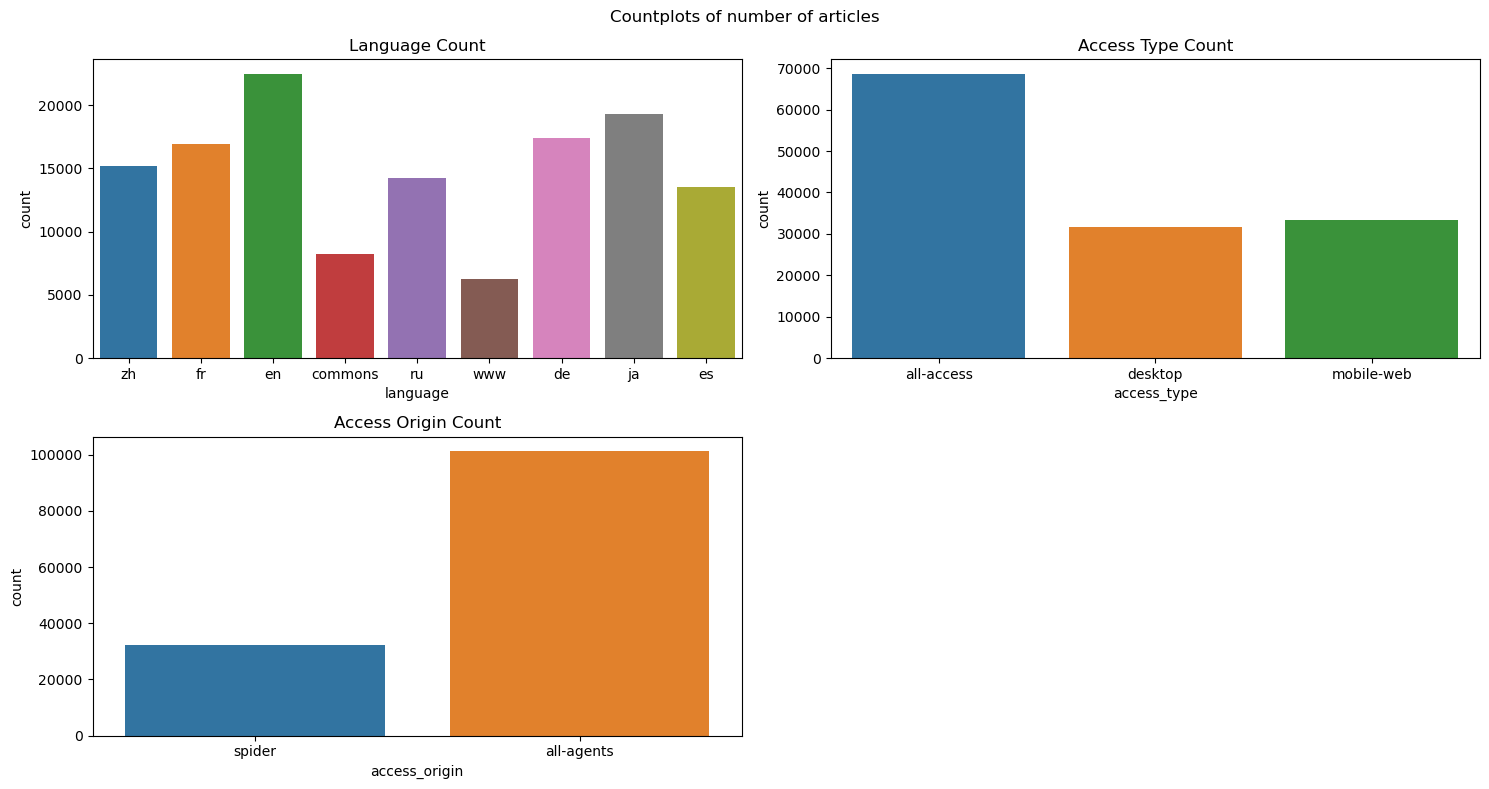

In [180]:
plt.figure(figsize=(15, 8))
plt.suptitle('Countplots of number of articles')

plt.subplot(2, 2, 1)
sns.countplot(x=df["language"], hue = df["language"])
plt.title("Language Count")

plt.subplot(2, 2, 2)
sns.countplot(x=df["access_type"], hue = df["access_type"] )
plt.title("Access Type Count")

if "access_origin" in df.columns:
    plt.subplot(2, 2, 3)
    sns.countplot(x=df["access_origin"], hue = df["access_origin"] )
    plt.title("Access Origin Count")

plt.tight_layout()
plt.show()

In [16]:
df['title'].nunique()

44491

In [17]:
df.shape

(133617, 554)

In [18]:
df.isna().sum()

title            0
language         0
access_type      0
access_origin    0
2015-07-01       0
                ..
2016-12-27       0
2016-12-28       0
2016-12-29       0
2016-12-30       0
2016-12-31       0
Length: 554, dtype: int64

In [19]:
df['title'].value_counts()

title
Special:Search                                                                                     35
Google                                                                                             30
YouTube                                                                                            29
Facebook                                                                                           28
IPhone                                                                                             24
                                                                                                   ..
Commons:Gambar_untuk_hari_ini                                                                       1
File:-LOVE-love-36983825-1680-1050.jpg                                                              1
File:03-05-2014_-_Graffiti_near_European_Central_Bank_-_EZB_-_Frankfurt_Main_-_Germany_-_01.jpg     1
File:15th_century_egyptian_anatomy_of_horse.jpg                             

In [20]:
df['language'].value_counts()

language
en         22486
ja         19295
de         17362
fr         16948
zh         15211
ru         14270
es         13551
commons     8266
www         6228
Name: count, dtype: int64

In [21]:
df['language'].nunique()

9

In [22]:
df.dtypes

title             object
language          object
access_type       object
access_origin     object
2015-07-01       float64
                  ...   
2016-12-27       float64
2016-12-28       float64
2016-12-29       float64
2016-12-30       float64
2016-12-31       float64
Length: 554, dtype: object

In [23]:
df['access_type'].unique()

array(['all-access', 'desktop', 'mobile-web'], dtype=object)

In [27]:
## Grouping on language and deriving mean visits for each language on each day.

exclude_cols = ['title', 'language', 'access_type', 'access_origin']

df_temp = df.groupby('language').agg({col: 'mean' for col in df.columns if col not in exclude_cols}).reset_index()

In [28]:
df_temp

,language,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,commons,137.917614,142.449189,139.099685,115.011493,127.912896,145.855311,152.569320,168.919913,146.516453,...,199.363174,219.913501,173.677595,188.996734,228.720300,237.444108,228.058190,227.904065,227.333777,195.896564
1,de,763.765926,753.362861,723.074415,663.537323,771.358657,849.080636,823.422532,835.455305,804.329513,...,862.566755,872.653899,850.650443,1312.415102,1260.964290,1119.596936,1062.284069,1033.939062,981.786430,937.842875
2,en,3767.328604,3755.158765,3565.225696,3711.782932,3833.433025,4127.429067,3906.341724,3685.854621,3771.183714,...,5191.453438,4850.360002,5162.438451,5360.667704,6036.850129,6314.335275,6108.874144,6518.058525,5401.792360,5280.643467
3,es,1127.485204,1077.485425,990.895949,930.303151,1011.759575,1153.091801,1123.942440,1090.832190,1070.245812,...,931.332891,877.420486,840.156077,862.085529,1142.166556,1070.923400,1108.996753,1058.660320,807.551177,776.934322
4,fr,499.092872,502.297852,483.007553,516.275785,506.871666,528.072752,510.426481,501.033632,495.848124,...,658.231414,644.305818,622.796082,672.201204,903.697368,840.590217,783.585379,763.209169,710.502773,654.060656
5,ja,614.637160,705.813216,637.451671,800.897435,768.352319,669.544493,651.298938,647.372428,631.090645,...,687.559368,988.378855,869.984504,830.838974,795.836486,808.541436,807.430163,883.752786,979.278777,1228.720808
6,ru,663.199229,674.677015,625.329783,588.171829,626.385354,674.764681,659.297617,656.209530,672.200981,...,908.778697,900.445550,889.133357,1128.097477,1131.580448,998.374071,945.054730,909.352207,815.475123,902.600210
7,www,56.036127,61.494701,52.223988,49.482177,54.235549,62.849550,69.478484,59.679351,53.176943,...,51.962909,78.749037,72.972383,78.113198,44.341362,46.206326,112.867373,48.636159,61.438022,56.019428
8,zh,272.498521,272.906778,271.097167,273.712379,291.977713,293.490632,293.170337,300.824206,298.983433,...,335.948130,328.966998,346.021103,364.817763,365.959372,363.066991,369.049701,340.526330,342.745316,352.184275


In [29]:
df_temp = df_temp.T

In [30]:
df_temp

,0,1,2,3,4,5,6,7,8
language,commons,de,en,es,fr,ja,ru,www,zh
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.9234,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.05819,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.05473,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.66032,763.209169,883.752786,909.352207,48.636159,340.52633
2016-12-30,227.333777,981.78643,5401.79236,807.551177,710.502773,979.278777,815.475123,61.438022,342.745316


In [31]:
df_temp.columns = df_temp.iloc[0]

In [32]:
df_temp

language,commons,de,en,es,fr,ja,ru,www,zh
language,commons,de,en,es,fr,ja,ru,www,zh
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.9234,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.05819,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.05473,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.66032,763.209169,883.752786,909.352207,48.636159,340.52633
2016-12-30,227.333777,981.78643,5401.79236,807.551177,710.502773,979.278777,815.475123,61.438022,342.745316


In [33]:
df_temp = df_temp[df_temp['commons'] != 'commons']

In [34]:
df_temp

language,commons,de,en,es,fr,ja,ru,www,zh
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.9234,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.05819,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.05473,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.66032,763.209169,883.752786,909.352207,48.636159,340.52633
2016-12-30,227.333777,981.78643,5401.79236,807.551177,710.502773,979.278777,815.475123,61.438022,342.745316


In [35]:
df_temp.columns

Index(['commons', 'de', 'en', 'es', 'fr', 'ja', 'ru', 'www', 'zh'], dtype='object', name='language')

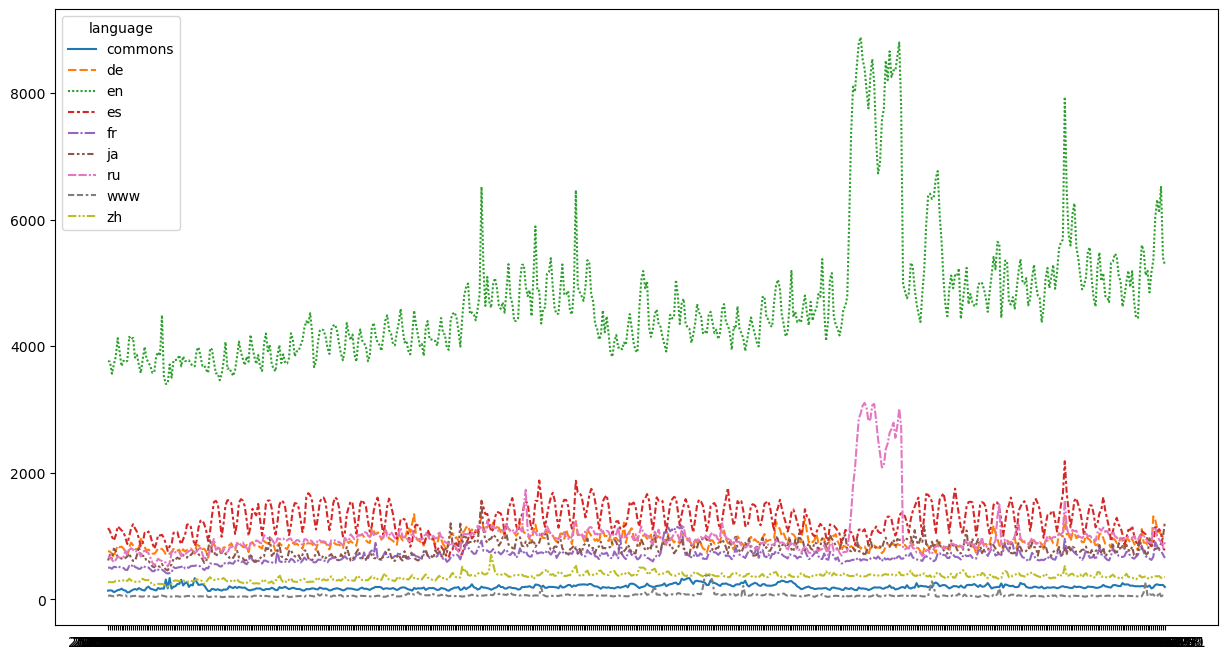

In [36]:
plt.figure(figsize = (15,8))
sns.lineplot(data = df_temp)
plt.show()

#### As we can see 'english' is clear winner among all other languages in terms of number of visits.

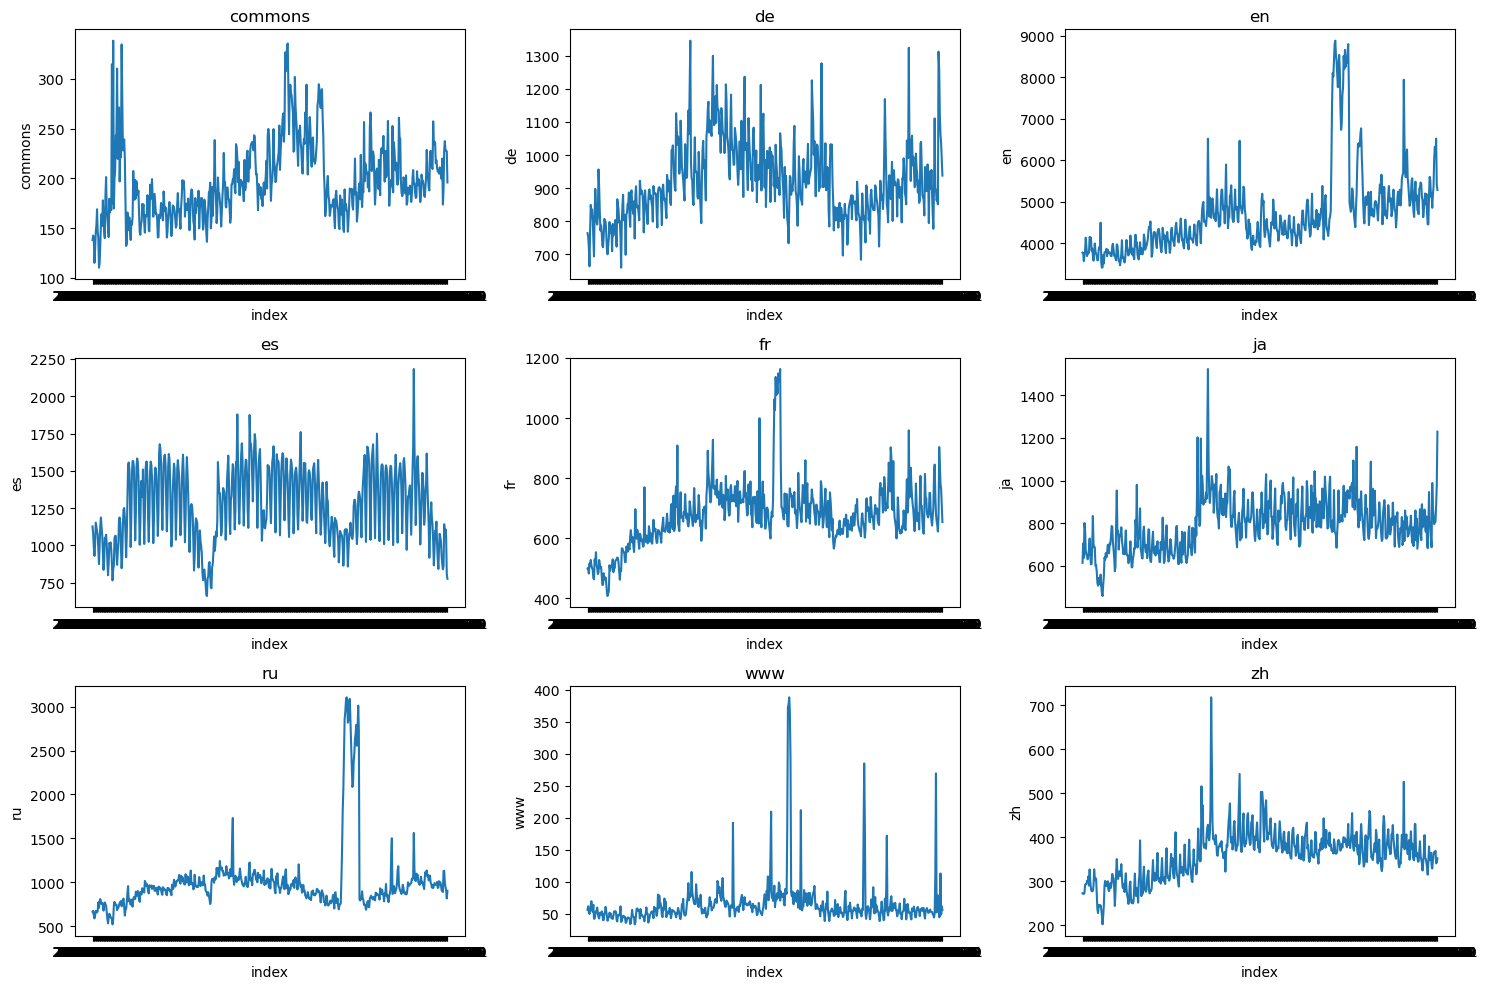

In [174]:
## Total visits for each language throughout the time range. 

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

columns = ['commons', 'de', 'en', 'es', 'fr', 'ja', 'ru', 'www', 'zh']

axes = axes.flatten()

for i, col in enumerate(columns):
    sns.lineplot(data=df_temp[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.show()

In [38]:
exclude_cols = ['title', 'language', 'access_type', 'access_origin']

df_temp1 = df.groupby('access_type').agg({col: 'mean' for col in df.columns if col not in exclude_cols})

In [39]:
df_temp1.head()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
access_type,,,,,,,,,,,,,,,,,,,,,
all-access,1086.976687,1100.218924,1034.413065,1069.326406,1113.433263,1177.058616,1128.118761,1091.906356,1097.381443,1087.941675,...,1415.996973,1401.762333,1429.495649,1558.690489,1719.679807,1720.417722,1668.579819,1721.85829,1504.575977,1506.662577
desktop,1261.859494,1271.058956,1135.225823,1063.252310,1120.945285,1374.119937,1326.001361,1255.191044,1270.042532,1245.942215,...,1734.248671,1531.140032,1448.334272,1478.615380,1734.199051,1794.371772,1779.825918,1777.74019,1550.031741,1452.075475
mobile-web,1023.979129,1015.645935,1027.093516,1157.030181,1187.939518,1093.973813,1042.675756,1025.856692,1020.639329,1028.211478,...,1102.038019,1247.719211,1364.003243,1570.417760,1642.508033,1587.911979,1515.923932,1642.47617,1415.359050,1535.473378


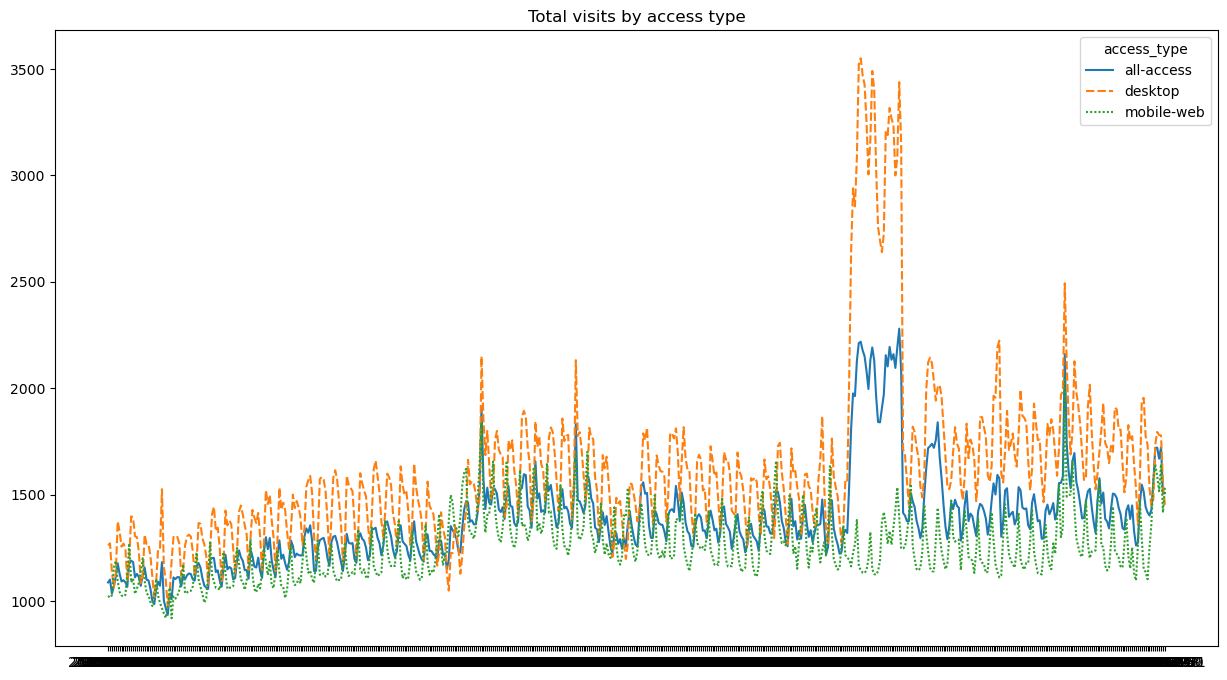

In [40]:
plt.figure(figsize = (15,8))
sns.lineplot(data = df_temp1.transpose())
plt.title("Total visits by access type")
plt.show()

In [41]:
exclude_cols = ['title', 'language', 'access_type', 'access_origin']

df_temp2 = df.groupby(['language','access_type']).agg({col: 'mean' for col in df.columns if col not in exclude_cols})

In [42]:
df_temp2 = df_temp2.reset_index()

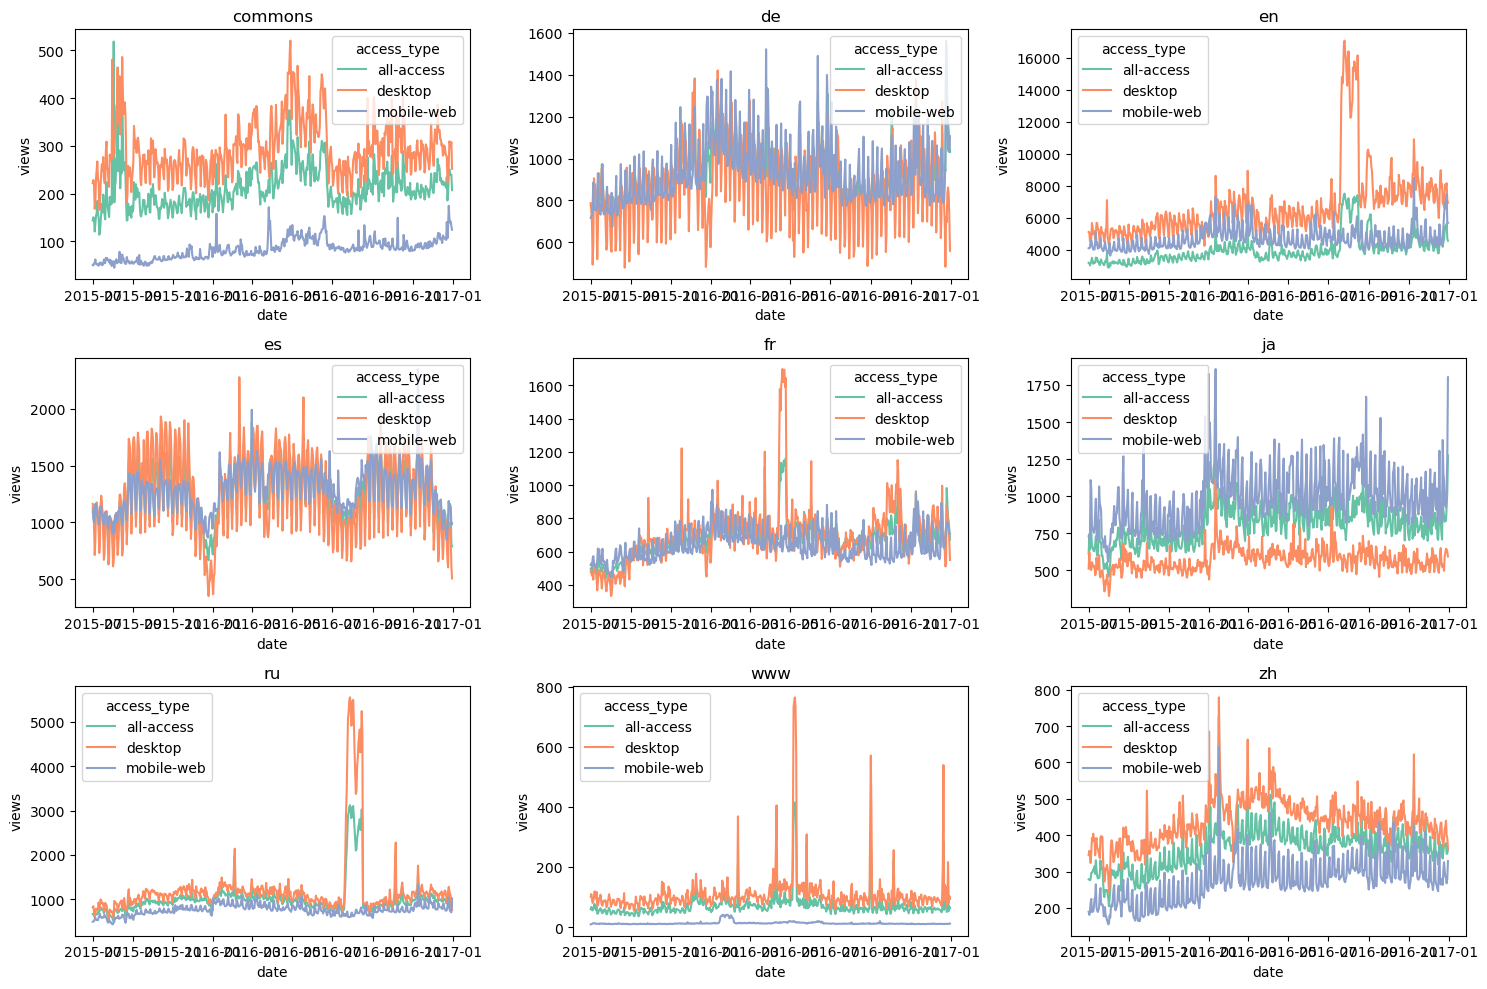

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

columns = ['commons', 'de', 'en', 'es', 'fr', 'ja', 'ru', 'www', 'zh']

# Flatten axes for iteration
axes = axes.flatten()

# Convert wide-format to long-format (Melt DataFrame)
df_melted = df_temp2.melt(id_vars=['language', 'access_type'], var_name='date', value_name='views')

# Convert 'date' to datetime format
df_melted['date'] = pd.to_datetime(df_melted['date'])

# Plot each language
for i, col in enumerate(columns):
    sns.lineplot(
        data=df_melted[df_melted['language'] == col],  # Filter for the current language
        x='date', 
        y='views', 
        hue='access_type', 
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [44]:
df_temp = df_temp.reset_index()
df_temp .head()

language,index,commons,de,en,es,fr,ja,ru,www,zh
0,2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
1,2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2,2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
3,2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
4,2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713


In [45]:
df_temp = df_temp.set_index('index')
df_temp.head()

language,commons,de,en,es,fr,ja,ru,www,zh
index,,,,,,,,,
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713


In [46]:
df_temp

language,commons,de,en,es,fr,ja,ru,www,zh
index,,,,,,,,,
2015-07-01,137.917614,763.765926,3767.328604,1127.485204,499.092872,614.63716,663.199229,56.036127,272.498521
2015-07-02,142.449189,753.362861,3755.158765,1077.485425,502.297852,705.813216,674.677015,61.494701,272.906778
2015-07-03,139.099685,723.074415,3565.225696,990.895949,483.007553,637.451671,625.329783,52.223988,271.097167
2015-07-04,115.011493,663.537323,3711.782932,930.303151,516.275785,800.897435,588.171829,49.482177,273.712379
2015-07-05,127.912896,771.358657,3833.433025,1011.759575,506.871666,768.352319,626.385354,54.235549,291.977713
...,...,...,...,...,...,...,...,...,...
2016-12-27,237.444108,1119.596936,6314.335275,1070.9234,840.590217,808.541436,998.374071,46.206326,363.066991
2016-12-28,228.05819,1062.284069,6108.874144,1108.996753,783.585379,807.430163,945.05473,112.867373,369.049701
2016-12-29,227.904065,1033.939062,6518.058525,1058.66032,763.209169,883.752786,909.352207,48.636159,340.52633


In [47]:
## Extracting english language

df_en = df_temp['en']
df_en.head()

index
2015-07-01    3767.328604
2015-07-02    3755.158765
2015-07-03    3565.225696
2015-07-04    3711.782932
2015-07-05    3833.433025
Name: en, dtype: object

In [48]:
english = pd.DataFrame(df_en.apply(round))

In [49]:
english.head()

,en
index,
2015-07-01,3767
2015-07-02,3755
2015-07-03,3565
2015-07-04,3712
2015-07-05,3833


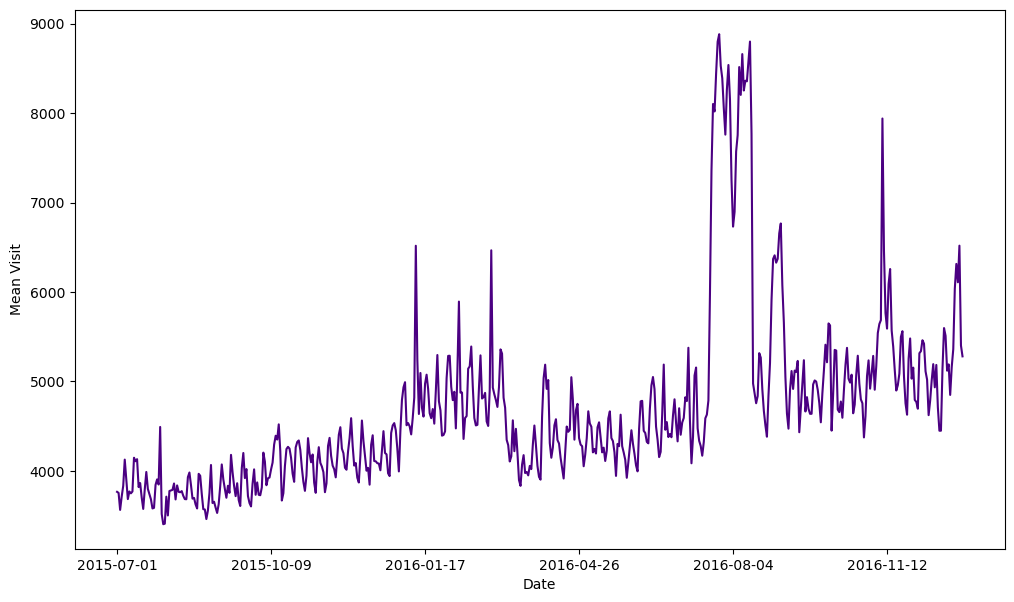

In [50]:
english['en'].plot(figsize=(12,7),color = 'indigo')
plt.xlabel('Date')
plt.ylabel('Mean Visit')
plt.show()

### Checking Stationarity using dickey-fuller test

In [52]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [53]:
def check_stationarity(data):

    """
    Inputs a time series performs the dickey-fuller test and print the results
    """
    
    adfuller_result = adfuller(data)
    p_value = adfuller_result[1]
    
    if p_value < 0.05:
        return "time series is stationary"
    else:
        return "time series is not stationary"   

In [54]:
check_stationarity(english)

'time series is not stationary'

#### We see that the p value is not low enough(<0.05). Therefore, we can say our series in not stationary as we fail to reject the null hypothesis

In [56]:
data = english['en']

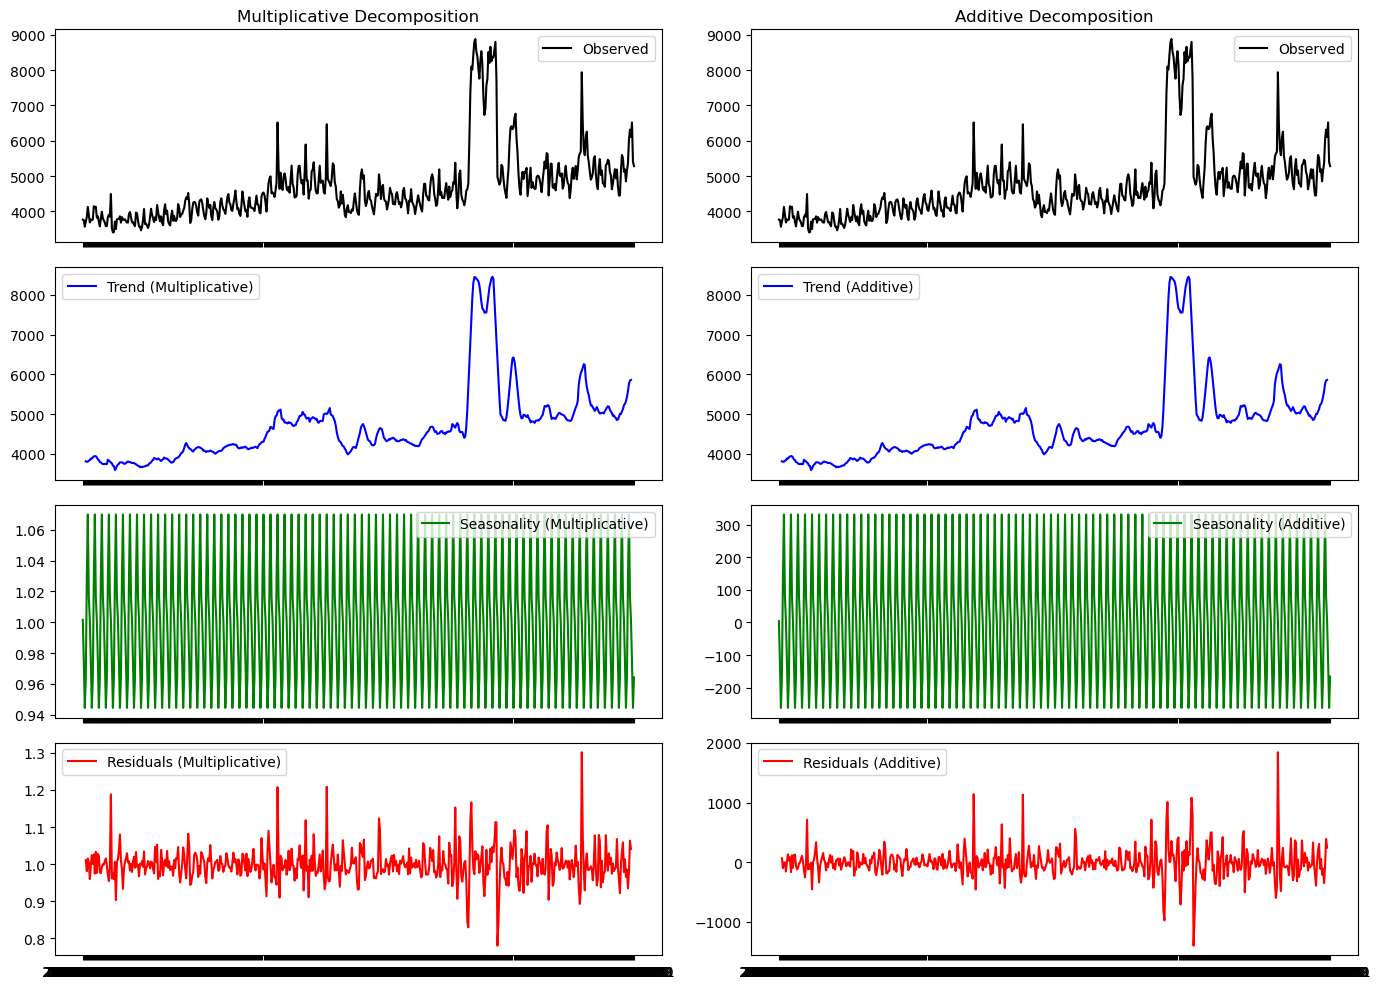

In [57]:
# Perform Multiplicative Decomposition
decomposition_mul = seasonal_decompose(data, model='multiplicative', period=7)

# Perform Additive Decomposition
decomposition_add = seasonal_decompose(data, model='additive', period=7)

# Extract Components
observed = data
trend_mul, trend_add = decomposition_mul.trend, decomposition_add.trend
seasonal_mul, seasonal_add = decomposition_mul.seasonal, decomposition_add.seasonal
residual_mul, residual_add = decomposition_mul.resid, decomposition_add.resid

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

axes[0, 0].set_title("Multiplicative Decomposition")
axes[0, 1].set_title("Additive Decomposition")

axes[0, 0].plot(observed, label="Observed", color="black")
axes[0, 1].plot(observed, label="Observed", color="black")

axes[1, 0].plot(trend_mul, label="Trend (Multiplicative)", color="blue")
axes[1, 1].plot(trend_add, label="Trend (Additive)", color="blue")

axes[2, 0].plot(seasonal_mul, label="Seasonality (Multiplicative)", color="green")
axes[2, 1].plot(seasonal_add, label="Seasonality (Additive)", color="green")

axes[3, 0].plot(residual_mul, label="Residuals (Multiplicative)", color="red")
axes[3, 1].plot(residual_add, label="Residuals (Additive)", color="red")

for ax_row in axes:
    for ax in ax_row:
        ax.legend(loc="best")

plt.tight_layout()
plt.show()

#### We can see that additive model shows less variance meaning additive model is fiiting better than multiplicative model.

In [59]:
## Checking the stationarity of residuals

residual_add = pd.DataFrame(residual_add).fillna(0)

In [60]:
residual_add.head()

,resid
index,
2015-07-01,0.000000
2015-07-02,0.000000
2015-07-03,0.000000
2015-07-04,68.502888
2015-07-05,-98.097844


In [61]:
check_stationarity(residual_add)

'time series is stationary'

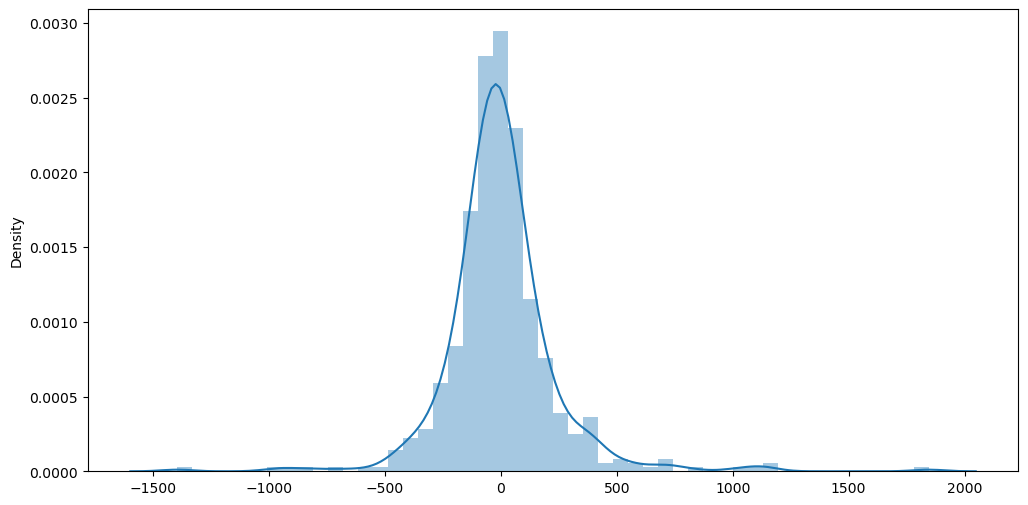

In [62]:
## Plotting the residual to check normality

plt.figure(figsize = (12,6))
sns.distplot(residual_add)
plt.show()

### Remove trend and seasonality with differencing

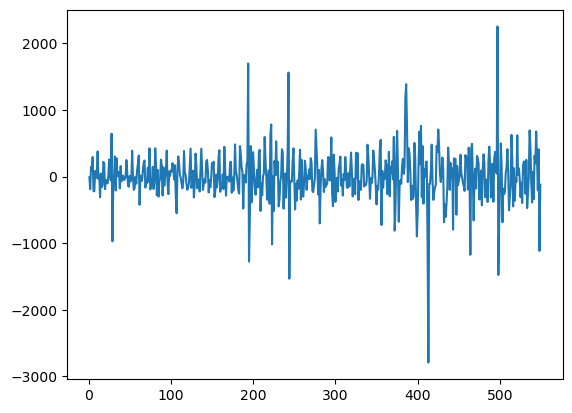

In [64]:
data_diff = data - data.shift(1)
plt.plot(data_diff.values)
plt.show()

In [65]:
data_diff.dropna(inplace = True)
check_stationarity(data_diff)

'time series is stationary'

### Plot the autocorreltaion and partial auto correlation functions

<Figure size 1200x600 with 0 Axes>

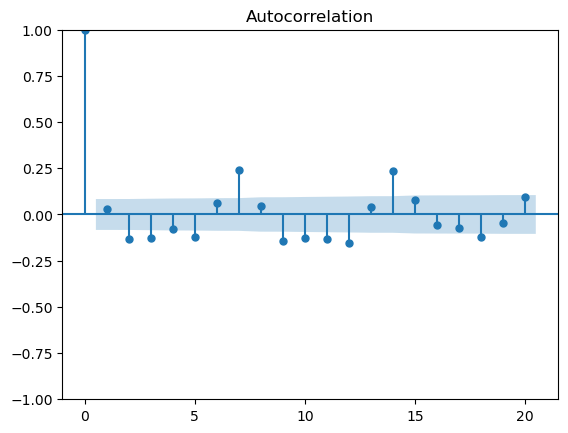

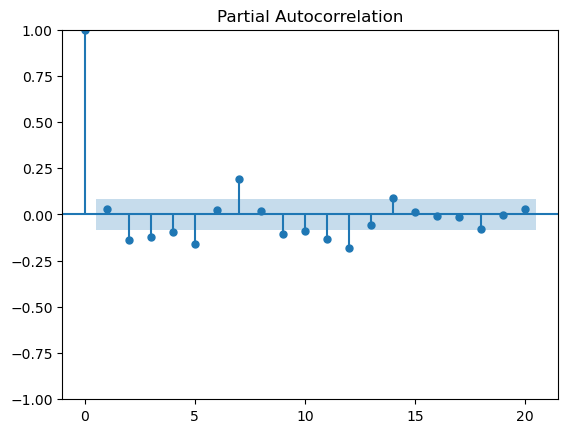

In [67]:
plt.figure(figsize = (12,6))
acf=plot_acf(data_diff,lags=20)
pacf=plot_pacf(data_diff,lags=20)
plt.show()

#### For p we use PACF, till 5 there are significant lines, if we want our model to be simpler we can start with a smaller number like 3/4.
#### We use ACF for q. here we can see that lag 4 is below significant level so we will use till lag 3

## ARIMA Model

In [70]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [71]:
train = data[:-20]
test = data[-20:]

In [72]:
test = pd.DataFrame(test)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 510.524
RMSE : 683.219
MAPE: 0.09


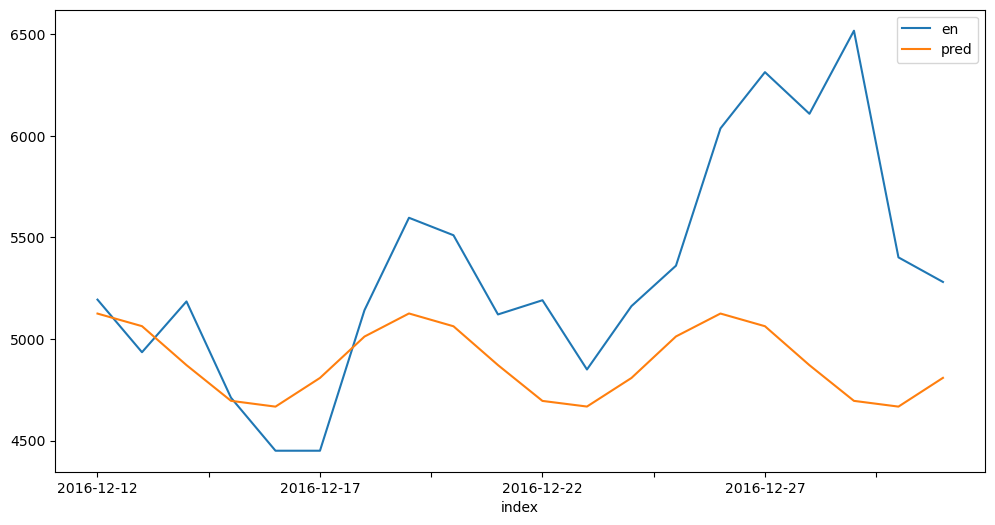

In [73]:
model_ARIMA = SARIMAX(train, order = (4,1,3))

arima_fit = model_ARIMA.fit(disp = -1)
test['pred'] = arima_fit.forecast(steps = 20)

performance(test['en'],test['pred'])
test.plot(figsize = (12,6))
plt.show()

### SARIMA Model

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 306.749
RMSE : 462.825
MAPE: 0.054


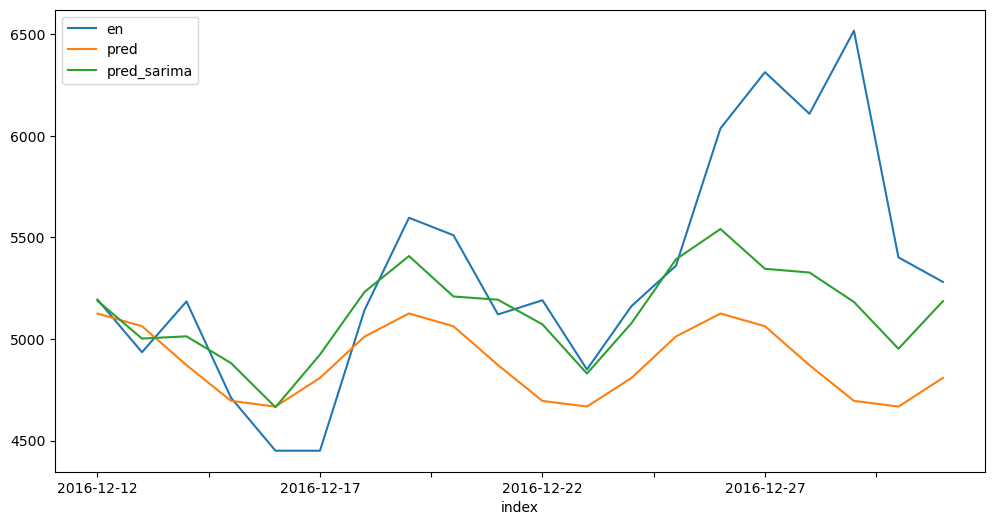

In [75]:
model_SARIMA = SARIMAX(train, order = (4,1,3),seasonal_order = (1,1,1,7))

sarima_fit = model_SARIMA.fit(disp = 0)
test['pred_sarima'] = sarima_fit.forecast(steps = 20)

performance(test['en'],test['pred_sarima'])
test.plot(figsize = (12,6))
plt.show()

### SARIMAX Model

In [77]:
## Getting the exogenous variable

exog = pd.read_csv("Exog_Campaign_eng")

In [78]:
exo = pd.DataFrame(exog)
exog_series = exog["Exog"]

In [79]:
exog.dtypes

Exog    int64
dtype: object

In [80]:
english_1 = pd.DataFrame(english.reset_index())

In [81]:
english_1

,index,en
0,2015-07-01,3767
1,2015-07-02,3755
2,2015-07-03,3565
3,2015-07-04,3712
4,2015-07-05,3833
...,...,...
545,2016-12-27,6314
546,2016-12-28,6109
547,2016-12-29,6518
548,2016-12-30,5402


In [82]:
df_exog = english_1.join(exo)
df_exog

,index,en,Exog
0,2015-07-01,3767,0
1,2015-07-02,3755,0
2,2015-07-03,3565,0
3,2015-07-04,3712,0
4,2015-07-05,3833,0
...,...,...,...
545,2016-12-27,6314,1
546,2016-12-28,6109,1
547,2016-12-29,6518,1
548,2016-12-30,5402,0


In [83]:
df_exog = df_exog.set_index('index')

In [84]:
df_exog.head()

,en,Exog
index,,
2015-07-01,3767,0
2015-07-02,3755,0
2015-07-03,3565,0
2015-07-04,3712,0
2015-07-05,3833,0


In [85]:
train_SARIMAX = df_exog[:-20]
test_SARIMAX = df_exog[-20:]

In [86]:
start = len(train_SARIMAX)
end = len(train_SARIMAX) + len(test_SARIMAX) - 1

In [185]:
model_SARIMAX = SARIMAX(train_SARIMAX['en'], order=(4, 1, 3), seasonal_order=(2, 1, 2, 7), exog=train_SARIMAX['Exog'])
model_SARIMAX_fitted = model_SARIMAX.fit(disp=0)

predictions = model_SARIMAX_fitted.predict(exog=test_SARIMAX['Exog'], start=start, end=end)

performance(test['en'], predictions)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE : 178.531
RMSE : 230.696
MAPE: 0.034


In [189]:
predictions

2016-12-12    5210.130877
2016-12-13    5050.206190
2016-12-14    4935.461981
2016-12-15    4876.638987
2016-12-16    4673.106917
2016-12-17    4947.864005
2016-12-18    5241.800800
2016-12-19    5418.375416
2016-12-20    5239.663371
2016-12-21    5136.191670
2016-12-22    5059.032834
2016-12-23    4858.299732
2016-12-24    5138.512593
2016-12-25    5420.952392
2016-12-26    5580.738466
2016-12-27    6436.694984
2016-12-28    6331.072283
2016-12-29    6238.138300
2016-12-30    4983.577209
2016-12-31    5265.839925
Freq: D, Name: predicted_mean, dtype: float64

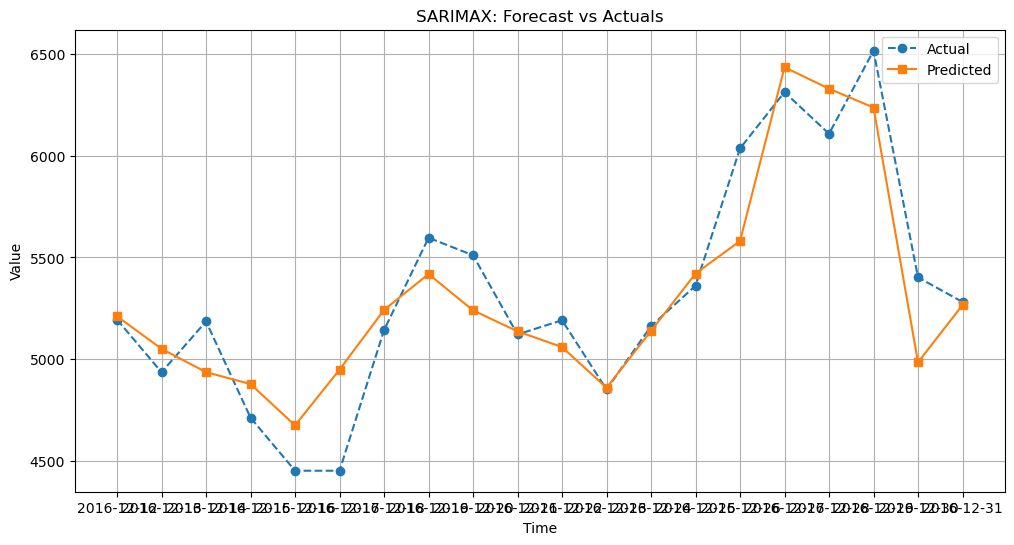

In [187]:
plt.figure(figsize=(12, 6))

## Plot actual values
plt.plot(test_SARIMAX.index, test_SARIMAX['en'], label='Actual', marker='o', linestyle='dashed')

## Plot predicted values
plt.plot(test_SARIMAX.index, predictions, label='Predicted', marker='s')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('SARIMAX: Forecast vs Actuals')
plt.legend()
plt.grid(True)

plt.show()

In [195]:
data = {  
    "Model": ["ARIMA", "SARIMA", "SARIMAX"],  
    "MAE": [510.524, 306.749, 178.531],  
    "RMSE": [683.219, 462.825, 230.696],  
    "MAPE": [0.09, 0.054, 0.034]  
}  

# Creating a DataFrame  
df = pd.DataFrame(data)  

df.style.set_properties(**{'text-align': 'center'})

,Model,MAE,RMSE,MAPE
0,ARIMA,510.524000,683.219000,0.090000
1,SARIMA,306.749000,462.825000,0.054000
2,SARIMAX,178.531000,230.696000,0.034000


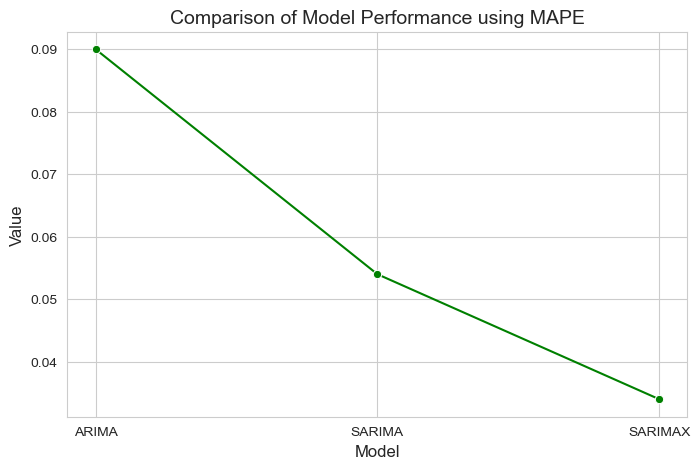

In [215]:
# Plot the data  
plt.figure(figsize=(8, 5))  
sns.lineplot(data=df, x="Model", y="MAPE",marker='o',color = 'green')  

# Add title and labels  
plt.title("Comparison of Model Performance using MAPE", fontsize=14)  
plt.xlabel("Model", fontsize=12)  
plt.ylabel("Value", fontsize=12)   
plt.show()

#### From the graph, SARIMAX performs the best among the three models as it has the lowest Mean Absolute Percentage Error (MAPE). This indicates that SARIMAX provides the most accurate predictions, likely due to its ability to incorporate exogenous variables. SARIMA outperforms ARIMA by capturing seasonality, leading to improved accuracy. ARIMA, which does not account for seasonality or external factors, performs the worst.